In [1]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

train_dir = "C:\\Users\\riley\\EPS 109\\Homework 11\\dd1\\training_set"
test_dir  = "C:\\Users\\riley\\EPS 109\\Homework 11\\dd1\\test_set"

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGE_WIDTH = 224
IMAGE_HEIGHT= 224
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

train_data_augmented = datasets.ImageFolder(train_dir, transform=train_transform)
test_data_augmented = datasets.ImageFolder(test_dir, transform=test_transform)

class_names = train_data_augmented.classes
print("Classes:", class_names)

NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32

train_dataloader_augmented = DataLoader(train_data_augmented, 
                                        batch_size=BATCH_SIZE, 
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_augmented = DataLoader(test_data_augmented, 
                                       batch_size=BATCH_SIZE, 
                                       shuffle=False, 
                                       num_workers=NUM_WORKERS)

class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer_1 = nn.Sequential(
          nn.Conv2d(3, 64, 3, padding=1),
          nn.ReLU(),
          nn.BatchNorm2d(64),
          nn.MaxPool2d(2))
        self.conv_layer_2 = nn.Sequential(
          nn.Conv2d(64, 512, 3, padding=1),
          nn.ReLU(),
          nn.BatchNorm2d(512),
          nn.MaxPool2d(2))
        self.conv_layer_3 = nn.Sequential(
          nn.Conv2d(512, 512, kernel_size=3, padding=1),
          nn.ReLU(),
          nn.BatchNorm2d(512),
          nn.MaxPool2d(2)) 
        self.classifier = nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=512*3*3, out_features=2))
    def forward(self, x: torch.Tensor):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_3(x)
        x = self.classifier(x)
        return x

model = ImageClassifier().to(device)

def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

from tqdm.auto import tqdm
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn=nn.CrossEntropyLoss(), epochs=5):
    results = {"train_loss": [],"train_acc": [],"test_loss": [],"test_acc": []}
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)
        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    return results

torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)
NUM_EPOCHS = 20

from timeit import default_timer as timer 
start_time = timer()

model_results = train(model=model,
                      train_dataloader=train_dataloader_augmented,
                      test_dataloader=test_dataloader_augmented,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

torch.save(model.state_dict(), "plants_vs_buildings_model.pth")
print("Model saved as plants_vs_buildings_model.pth")


Classes: ['buildings', 'plants']


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0976 | train_acc: 0.6859 | test_loss: 1.4287 | test_acc: 0.3906
Epoch: 2 | train_loss: 0.7922 | train_acc: 0.7577 | test_loss: 0.4462 | test_acc: 0.8359
Epoch: 3 | train_loss: 0.6549 | train_acc: 0.7511 | test_loss: 0.6004 | test_acc: 0.7734
Epoch: 4 | train_loss: 0.4118 | train_acc: 0.8383 | test_loss: 0.3326 | test_acc: 0.8359
Epoch: 5 | train_loss: 0.4227 | train_acc: 0.8627 | test_loss: 0.2279 | test_acc: 0.9297
Epoch: 6 | train_loss: 0.4135 | train_acc: 0.8572 | test_loss: 0.3070 | test_acc: 0.8594
Epoch: 7 | train_loss: 0.3878 | train_acc: 0.8788 | test_loss: 0.3605 | test_acc: 0.8594
Epoch: 8 | train_loss: 0.3262 | train_acc: 0.8960 | test_loss: 0.3450 | test_acc: 0.8984
Epoch: 9 | train_loss: 0.5344 | train_acc: 0.8647 | test_loss: 1.2673 | test_acc: 0.7500
Epoch: 10 | train_loss: 0.4617 | train_acc: 0.8503 | test_loss: 0.4834 | test_acc: 0.8359
Epoch: 11 | train_loss: 0.2918 | train_acc: 0.8939 | test_loss: 0.5610 | test_acc: 0.8594
Epoch: 12 | train_l

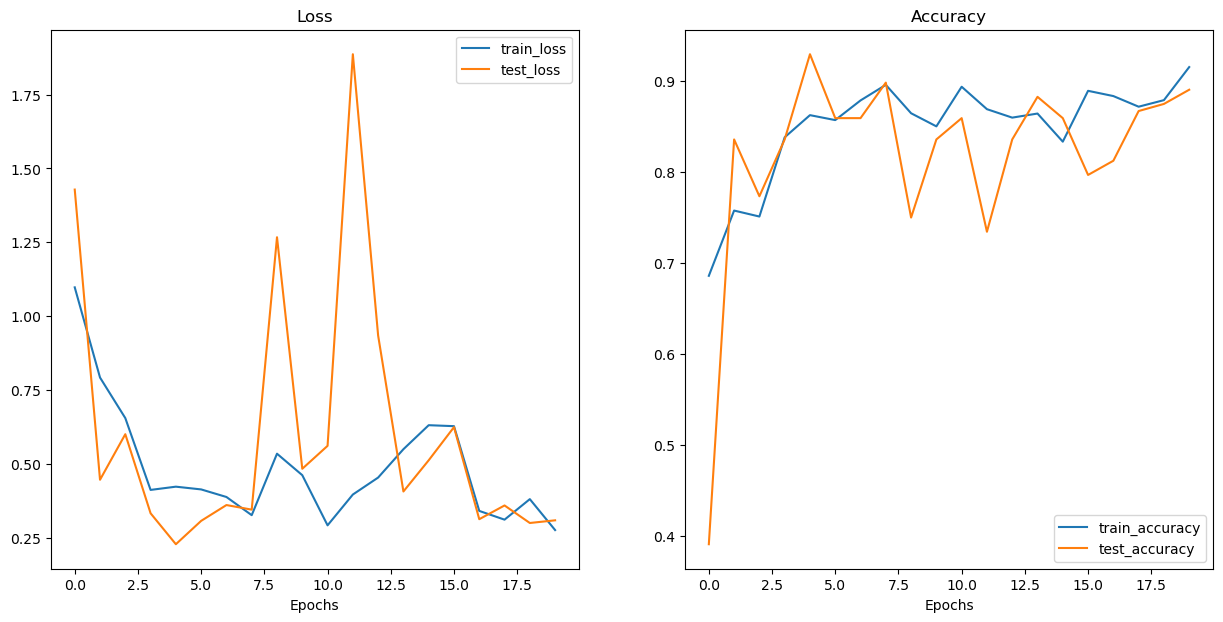

In [2]:
import matplotlib.pyplot as plt

# Plot the training progress.
# Discuss the resulting four curves with your GSI.
# Which is the best curve to assess whether this entire project was a success?
# We will refer to this curve as Q below.
def plot_loss_curves(results):
  
    results = dict(list(model_results.items()))

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot 
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

plot_loss_curves(model_results)

In [6]:
import glob
import numpy as np
from pathlib import Path
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

def ClassifyImagesInFolder(folder):
    image_path_list = glob.glob(folder + "/*")
    print("Number of images found:", len(image_path_list))

    numberOfImagesPerClass = np.zeros((2))
    
    misclassified_images = []

    custom_image_transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
    ])

    for custom_image_path in image_path_list:

        custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)
        custom_image = custom_image / 255.

        custom_image_transformed = custom_image_transform(custom_image)

        model.eval()
        with torch.inference_mode():
            custom_image_pred = model(custom_image_transformed.unsqueeze(dim=0).to(device))

        custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
        custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1).cpu().item()

        numberOfImagesPerClass[custom_image_pred_label] += 1

        true_label = Path(custom_image_path).parent.stem 
        true_label_index = class_names.index(true_label)

        if custom_image_pred_label != true_label_index:
            misclassified_images.append(custom_image_path)

    print("Count result:", numberOfImagesPerClass)
    print("Normalized result:", numberOfImagesPerClass / np.sum(numberOfImagesPerClass))

    if len(misclassified_images) > 0:
        print("\nShowing three misclassified images:\n")
        for img_path in misclassified_images[:3]:
            img = Image.open(img_path)
            plt.figure(figsize=(4,4))
            plt.imshow(img)
            plt.title(f"Misclassified: {Path(img_path).name}")
            plt.axis('off')
            plt.show()

    return numberOfImagesPerClass



FOLDER: C:\Users\riley\EPS 109\Homework 11\buildings
Number of images found: 800
Count result: [642. 158.]
Normalized result: [0.8025 0.1975]

Showing three misclassified images:



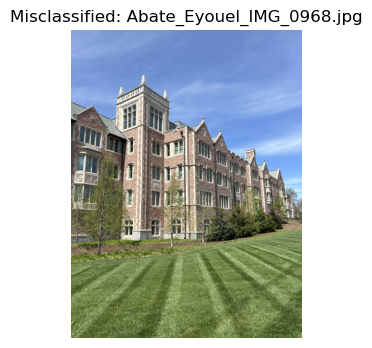

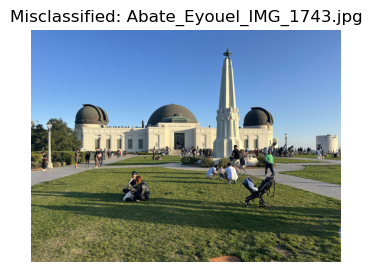

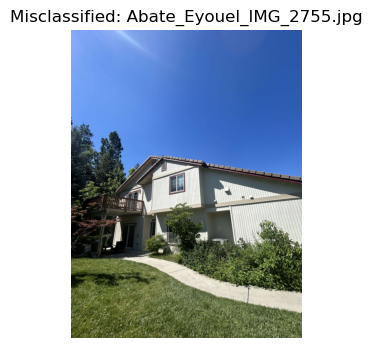


FOLDER: C:\Users\riley\EPS 109\Homework 11\plants
Number of images found: 799
Count result: [ 21. 778.]
Normalized result: [0.02628285 0.97371715]

Showing three misclassified images:



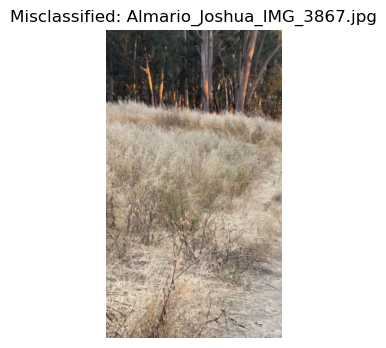

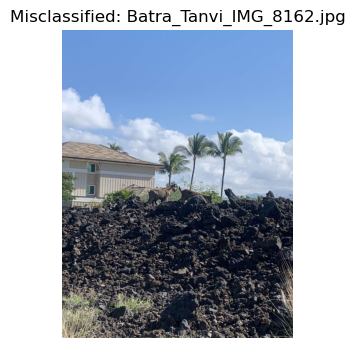

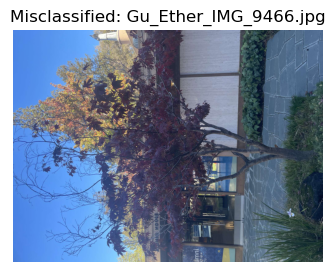

In [5]:
folders_to_check = [
    "C:\\Users\\riley\\EPS 109\\Homework 11\\buildings",
    "C:\\Users\\riley\\EPS 109\\Homework 11\\plants"
]

for f in folders_to_check:
    print("\nFOLDER:", f)
    result = ClassifyImagesInFolder(f)
